# Spatial dynamics of vaccination in a simple epidemiological model

_Author_: Joe Mihaljevic

The goal of this dev log is to demonstrate various methodologies to simulate vaccination in a spatial context, using `epymorph`. 
The routines will be purposefully simplified, as demonstration, and will build in complexity so that new users can understand how they might build their own vaccination modeling framework. 

## Simple SIRS-V model

Let's begin with a simple SIRS-V model of the form:
$\begin{align}
\frac{dS}{dt} &= -\frac{\beta SI}{N} - \nu + \delta R \\
\frac{dI}{dt} &= \frac{\beta SI}{N} - \gamma I \\
\frac{dR}{dt} &= \gamma I - \delta R \\
\frac{dV}{dt} &= \nu
\end{align}$

Here, we assume a standard SIR model with waning immunity (i.e., an SIRS).
For the vaccine class, $V$, we assume a constant linear rate of vaccine uptake, noted as parameter $\nu$. 
Although a constant linear rate is simplistic, we will see that, using `epymorph`, we can layer on complexity, such as by assuming a time- and/or location-varying rate of update (i.e., $\nu_{t,k}$, where $t$ is time, and $k$ is location).

### Setup for single-node simulation

First, we will run the model in a single location (i.e., node) using static parameter values. Let's assume we are running the model with a single node representing all of Cook County, IL. 

(1) Construct the intra-population model (IPM) as a compartmental model `class`

In [82]:
# REQUIRED IMPORTS
# import numpy as np
from sympy import Max

from epymorph import *
from epymorph.compartment_model import *
from epymorph.data_shape import Shapes
from epymorph.simulation import AttributeDef

In [83]:
class SIRV(CompartmentModel):
    """Defines a compartmental IPM."""

    compartments = [
        compartment("S"),
        compartment("I"),
        compartment("R"),
        compartment("V"),
    ]

    requirements = [
        AttributeDef("beta", type=float, shape=Shapes.TxN, comment="transmission rate"),
        AttributeDef("gamma", type=float, shape=Shapes.TxN, comment="recovery rate"),
        AttributeDef(
            "delta", type=float, shape=Shapes.TxN, comment="waning immunity rate"
        ),
        AttributeDef(
            "nu", type=float, shape=Shapes.TxN, comment="average vaccine allocation"
        ),
    ]

    def edges(self, symbols):
        [
            S,
            I,
            R,
            V,
        ] = symbols.all_compartments
        [
            beta,
            gamma,
            delta,
            nu,
        ] = symbols.all_requirements

        N = Max(1, S + I + R + V)

        return [
            edge(S, I, rate=beta * S * I / N),
            edge(I, R, rate=gamma * I),
            edge(R, S, rate=delta * R),
            edge(S, V, rate=nu),
        ]


We can use the `render` function to display a graphical representation of the model, which helps us double-check that we set it up correctly.

In [84]:
# render(SIRV())

(2) Specify the geographical scope in which you want to simulate your IPM. In this case, we're assuming a single location scope. We use the ADRIO system, and again, we'll assume the location is Cook County, IL, which has FIPS code `17031`. We'll specify a year related to the US Census data, here 2020. 

In [85]:
from epymorph.geography.us_census import CountyScope

In [86]:
cook_county = CountyScope.in_counties(["Cook, IL"], year=2020)
# Use the `labels` method to verify you go the right county
cook_county.labels

array(['Cook, IL'], dtype='<U8')

(3) Build the RUME (runnable modeling experiment), which requires various arguments, which we will display below:

In [87]:
from epymorph.adrio import acs5, us_tiger
from epymorph.data.mm.no import No as NoMovement

In [88]:
cook_rume = SingleStrataRume.build(
    # Load the SIRV IPM
    ipm=SIRV(),
    # This is where you specify a movement model. We don't have movement (single node)
    mm=NoMovement(),
    # Place your geographical scope, which we defined above
    scope=cook_county,
    # Create a SingleLocation initializer. 10 initially infected individuals in the node
    init=init.SingleLocation(location=0, seed_size=10),
    # Set the time-frame to simulate (100 days)
    time_frame=TimeFrame.of("2020-01-01", 100),
    # Provide model parameter values (IPM and MM)
    params={
        "beta": 0.9,
        "gamma": 0.5,
        "delta": 1 / 90.0,
        "nu": 5000.0,
        # Geographic data can be loaded using ADRIOs
        "population": acs5.Population(),
        "meta::geo::label": us_tiger.Name(),
    },
)

In [89]:
# Check to see if you specified required params and variables
cook_rume.requirements

OrderedDict([(AbsoluteName(strata='gpm:all', module='ipm', id='beta'),
              AttributeDef(name='beta', type=<class 'float'>, shape=TimeAndNode(), default_value=None, comment='transmission rate')),
             (AbsoluteName(strata='gpm:all', module='ipm', id='gamma'),
              AttributeDef(name='gamma', type=<class 'float'>, shape=TimeAndNode(), default_value=None, comment='recovery rate')),
             (AbsoluteName(strata='gpm:all', module='ipm', id='delta'),
              AttributeDef(name='delta', type=<class 'float'>, shape=TimeAndNode(), default_value=None, comment='waning immunity rate')),
             (AbsoluteName(strata='gpm:all', module='ipm', id='nu'),
              AttributeDef(name='nu', type=<class 'float'>, shape=TimeAndNode(), default_value=None, comment='average vaccine allocation')),
             (AbsoluteName(strata='gpm:all', module='init', id='population'),
              AttributeDef(name='population', type=<class 'int'>, shape=Node(), default_value=

(4) Generate a simulator, run the simulation, and store the output object

In [90]:
# Construct a simulator for the RUME
cook_sim = BasicSimulator(cook_rume)

# Run inside a sim_messaging context to display a nice progress bar
with sim_messaging():
    # Run and save the simulation Output object for later
    out_cook = cook_sim.run(
        # Use a seeded RNG (for the sake of keeping this notebook's results consistent)
        # This parameter is optional; by default a new RNG is constructed for each run
        # using numpy's default_rng
        rng_factory=default_rng(1)
    )

Running simulation (BasicSimulator):
• 2020-01-01 to 2020-04-10 (100 days)
• 1 geo nodes
  |####################| 100% 
Runtime: 0.011s


The output object is an `np.array` that holds the counts in the IPM compartments and the counts of new events, per node, per time.

In [91]:
# Raw output dimensions
out_cook.dim

SimDimensions(tau_step_lengths=(1.0,), tau_steps=1, start_date=datetime.date(2020, 1, 1), days=100, ticks=100, nodes=1, compartments=4, events=4, TNCE=(100, 1, 4, 4))

(5) Use internal plotting functions to check the output

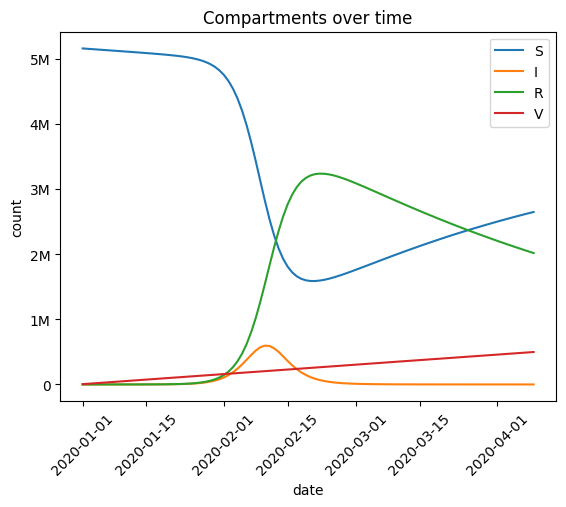

In [92]:
out_cook.plot.line(
    geo=cook_rume.scope.select.all(),
    time=cook_rume.time_frame.select.all(),
    quantity=cook_rume.ipm.select.compartments(),
    title="Compartments over time",
    label_format="{q}",
)


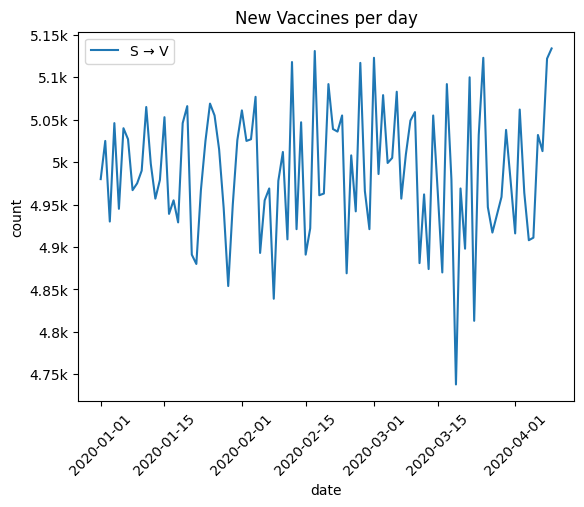

In [93]:
out_cook.plot.line(
    geo=cook_rume.scope.select.all(),
    time=cook_rume.time_frame.select.all(),
    quantity=cook_rume.ipm.select.events("S->V"),
    title="New Vaccines per day",
    label_format="{q}",
)

In [94]:
out_cook.table.chart(
    geo=cook_rume.scope.select.all(),
    time=cook_rume.time_frame.select.all(),
    quantity=cook_rume.ipm.select.all(),
)

,geo,quantity,chart
0,"Cook, IL",S,██████▇▅▄▃▃▃▄▄▄▄▄▄▄▅
1,"Cook, IL",I,▁▁▁▁▁▂▄█▆▃▂▁▁▁▁▁▁▁▁▁
2,"Cook, IL",R,▁▁▁▁▁▁▂▄▇███▇▇▇▆▆▆▆▅
3,"Cook, IL",V,▁▂▂▂▃▃▃▄▄▄▅▅▆▆▆▇▇▇██
4,"Cook, IL",S → I,▁▁▁▁▁▂▄██▄▂▁▁▁▁▁▁▁▁▁
5,"Cook, IL",I → R,▁▁▁▁▁▁▂▆█▅▂▁▁▁▁▁▁▁▁▁
6,"Cook, IL",R → S,▁▁▁▁▁▁▁▂▅▇███▇▇▇▆▆▆▆
7,"Cook, IL",S → V,████████████████████


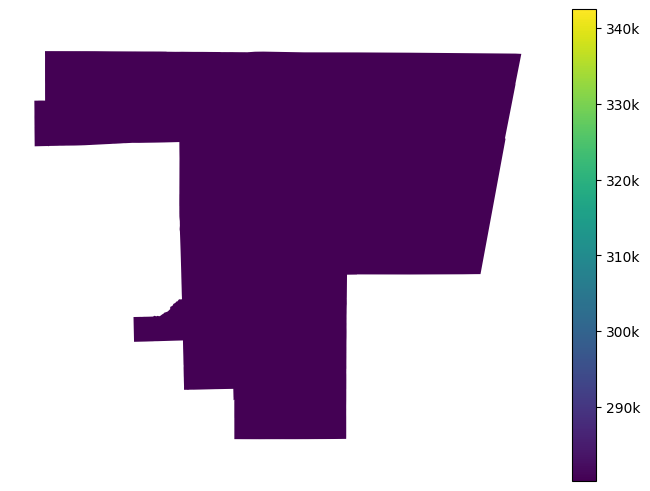

In [121]:
out_cook.map.choropleth(
    geo=cook_rume.scope.select.all(),
    time=cook_rume.time_frame.select.all().agg(events="max"),
    quantity=cook_rume.ipm.select.events("S->I"),
)

### Setup for multi-node simulation

Now we will setup and run a multi-node simulation, still in Cook County, IL, but now using the US Census Tracts as nodes in the model. 

In [ ]:
from epymorph.geography.us_census import TractScope

# Define the TractScope
cook_tract = TractScope.in_counties(["Cook, IL"], year=2020)


1

Now that we are dealing with a multi-node simulation, the Movement Model (MM) becomes more important to consider. 
Fortunately, `epymorph` has some pre-built MMs that range in complexity.
And, of course, a user could build their own MM if they wish. 
In this case, we are going to use a commuter-style movement model that is based by a paper by Pei et al. and applied to influenza spread among US states. 
You can check out the `pei.py` file in the `./data/mm/` directory to see the precise specification of the MM.  

In [ ]:
from epymorph.data.mm.pei import Pei as Commuter

commuter_MM = Commuter()

I'm going to purposely set up the RUME with some missing attributes, so that we can check those and revise.

In [ ]:
cook_tract_rume_INCOMPLETE = SingleStrataRume.build(
    # Load the SIRV IPM
    ipm=SIRV(),
    # This is where you specify a movement model. We don't have movement (single node)
    mm=commuter_MM,
    # Place your geographical scope, which we defined above
    scope=cook_tract,
    # Create a SingleLocation initializer. 10 initially infected individuals in the node
    init=init.SingleLocation(location=0, seed_size=10),
    # Set the time-frame to simulate (100 days)
    time_frame=TimeFrame.of("2020-01-01", 70),
    # Provide model parameter values (IPM and MM)
    params={
        "beta": 0.9,
        "gamma": 0.5,
        "delta": 1 / 90.0,
        "nu": 50.0,
        # Geographic data can be loaded using ADRIOs
        "population": acs5.Population(),
        "meta::geo::label": us_tiger.Name(),
    },
)

# check requirements
cook_tract_rume_INCOMPLETE.requirements

OrderedDict([(AbsoluteName(strata='gpm:all', module='ipm', id='beta'),
              AttributeDef(name='beta', type=<class 'float'>, shape=TimeAndNode(), default_value=None, comment='transmission rate')),
             (AbsoluteName(strata='gpm:all', module='ipm', id='gamma'),
              AttributeDef(name='gamma', type=<class 'float'>, shape=TimeAndNode(), default_value=None, comment='recovery rate')),
             (AbsoluteName(strata='gpm:all', module='ipm', id='delta'),
              AttributeDef(name='delta', type=<class 'float'>, shape=TimeAndNode(), default_value=None, comment='waning immunity rate')),
             (AbsoluteName(strata='gpm:all', module='ipm', id='nu'),
              AttributeDef(name='nu', type=<class 'float'>, shape=TimeAndNode(), default_value=None, comment='average vaccine allocation')),
             (AbsoluteName(strata='gpm:all', module='mm', id='commuters'),
              AttributeDef(name='commuters', type=<class 'int'>, shape=NodeAndNode(), default_val

We can see that the MM requires three pieces that are missing from our initial RUME setup. 
The attribute `commuters` is an `NxN` array (see `shape` specification), which tells the model how many commuters move from one location to the next. 
We're going to use the LODES Adrio to fill this in. LODES is a data set based off of survey data in the US Census that estimates the number of individuals that commute away from their home census delineation for work. 
Parameters `move_control` and `theta` determine how much movement randomly deviates from the `commuters` array on a daily basis. 
These two parameters have useful defaults, so we won't change those.  

In [ ]:
from epymorph.adrio import lodes

# Re-specify the RUME
cook_tract_rume = SingleStrataRume.build(
    # Load the SIRV IPM
    ipm=SIRV(),
    # This is where you specify a movement model. We don't have movement (single node)
    mm=commuter_MM,
    # Place your geographical scope, which we defined above
    scope=cook_tract,
    # Create a SingleLocation initializer. 10 initially infected individuals in the node
    init=init.SingleLocation(location=0, seed_size=10),
    # Set the time-frame to simulate (100 days)
    time_frame=TimeFrame.of("2020-01-01", 70),
    # Provide model parameter values (IPM and MM)
    params={
        # IPM requires:
        "beta": 0.9,
        "gamma": 0.5,
        "delta": 1 / 90.0,
        "nu": 5.0,
        # MM requires:
        "commuters": lodes.Commuters(2020, "All Jobs"),
        # Geographic data can be loaded using ADRIOs
        "population": acs5.Population(),
        "meta::geo::label": us_tiger.Name(),
    },
)


Construct and run the simulation. Note, this might take some time because of how many nodes we're dealing with. We also need to import new data. We can estimate how long the data importation might take.

In [115]:
cook_tract_rume.estimate_data()

ADRIO data usage estimation:
- epymorph.adrio.lodes.Commuters will be pulled from cache
- epymorph.adrio.acs5.Population (no estimate available)
- epymorph.adrio.us_tiger.Name will be pulled from cache
In total we will:
- Download no additional data
- Write no new data to disk cache


In [116]:
# Construct a simulator for the RUME
cook_tract_sim = BasicSimulator(cook_tract_rume)

# Run inside a sim_messaging context to display a nice progress bar
with sim_messaging():
    # Run and save the simulation Output object for later
    out_cook_tract = cook_tract_sim.run(
        # Use a seeded RNG (for the sake of keeping this notebook's results consistent)
        # This parameter is optional; by default a new RNG is constructed for each run
        # using numpy's default_rng
        rng_factory=default_rng(1)
    )

Loading epymorph.adrio.lodes.Commuters:
  |####################| 100%  (49.884s)
Running simulation (BasicSimulator):
• 2020-01-01 to 2020-03-11 (70 days)
• 1332 geo nodes
  |####################| 100% 
Runtime: 116.901s


For me, with about 1,300 nodes in the scope, the simulation of 70 days took 2 minutes to run (on  my laptop). 
But the initial data download and behind-the-scenes munging of the LODES Adrio took abou 1.5 minutes. 
If I run this simulation again, those LODES data will be cached and ready to go. 
However, the data will still need to be munged. 
For instance, on second run, the LODES data took 50 seconds to complete munging.

In [105]:
out_cook_tract.dim

SimDimensions(tau_step_lengths=(0.3333333333333333, 0.6666666666666666), tau_steps=2, start_date=datetime.date(2020, 1, 1), days=70, ticks=140, nodes=1332, compartments=4, events=4, TNCE=(140, 1332, 4, 4))

Notice now that we have 140 time `ticks`, rather than 70. 
This is because within the movement model, we have a single day divided into two transmission windows: the period of working hours, and the period of 'at-home'. 

In [117]:
out_cook_tract.table.range(
    geo=cook_tract_rume.scope.select.all(),
    time=cook_tract_rume.time_frame.select.all(),
    quantity=cook_tract_rume.ipm.select.events("S->I"),
)

,geo,quantity,min,max
0,17031010100,S → I,0.0,210.0
1,17031010201,S → I,0.0,308.0
2,17031010202,S → I,0.0,119.0
3,17031010300,S → I,0.0,243.0
4,17031010400,S → I,0.0,217.0
...,...,...,...,...
1327,17031844600,S → I,0.0,66.0
1328,17031844700,S → I,0.0,48.0
1329,17031980000,S → I,0.0,428.0
1330,17031980100,S → I,0.0,70.0


In [ ]:
# AGGREGATE TO STATE:
# Calculate the maximum Infected individuals observed across the county at any time
out_cook_tract.table.range(
    geo=cook_tract_rume.scope.select.all().group_by("county").sum(),
    time=cook_tract_rume.time_frame.select.all(),
    quantity=cook_tract_rume.ipm.select.compartments("I"),
)

,geo,quantity,min,max
0,"Cook, IL",I,15.0,544221.0


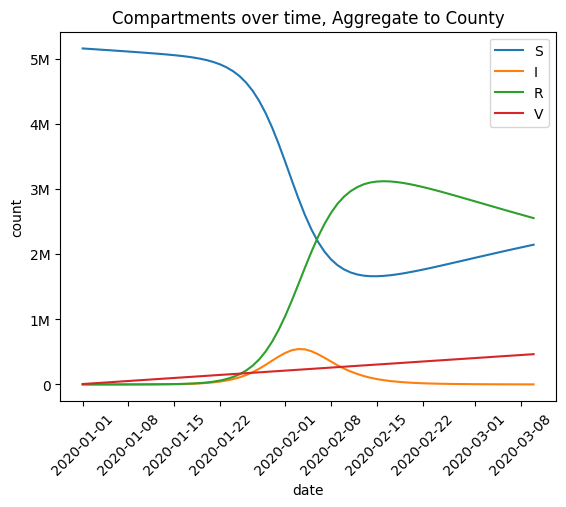

In [ ]:
out_cook_tract.plot.line(
    geo=cook_tract_rume.scope.select.all().group_by("county").sum(),
    time=cook_tract_rume.time_frame.select.all(),
    quantity=cook_tract_rume.ipm.select.compartments(),
    title="Compartments over time, Aggregate to County",
    label_format="{q}",
)

You can see roughly the same dynamics when aggregated, but let's see the individual tracts. 
We'll remove the labels, because we'll have >1,000 lines.

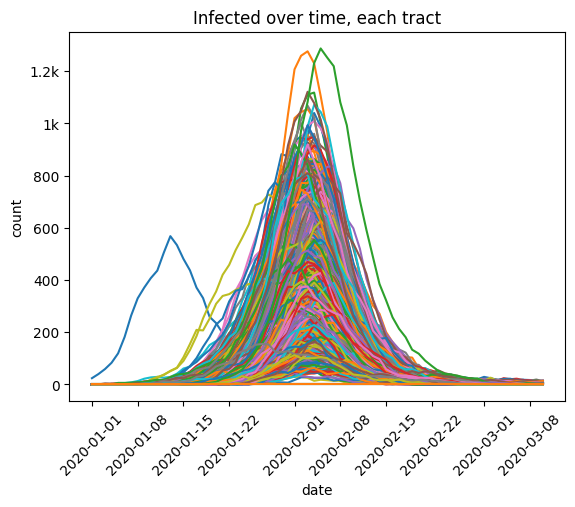

In [ ]:
out_cook_tract.plot.line(
    geo=cook_tract_rume.scope.select.all(),
    time=cook_tract_rume.time_frame.select.all(),
    quantity=cook_tract_rume.ipm.select.compartments("I"),
    title="Infected over time, each tract",
    # label_format="{q}",
    legend="off",
)

We can map the max Infected per Tract:

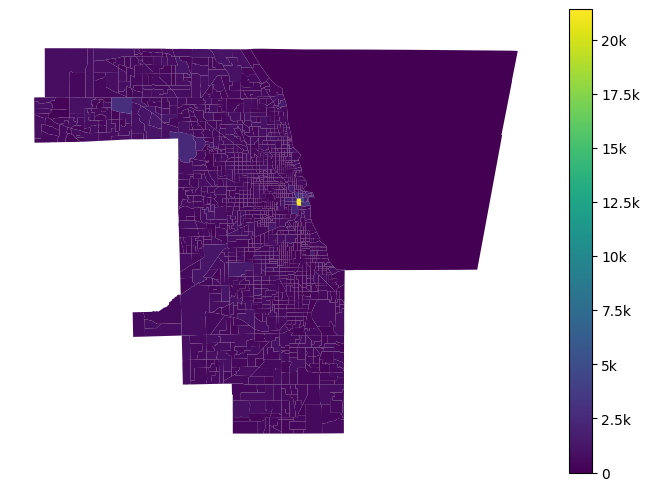

In [128]:
out_cook_tract.map.choropleth(
    geo=cook_tract_rume.scope.select.all(),
    time=cook_tract_rume.time_frame.select.all().agg(compartments="max"),
    quantity=cook_tract_rume.ipm.select.compartments("I"),
)

TYLER: I think I see a bug. In the map, there is a single tract with a max Infected ~20k; however, in the line plot above, it seems that tract is somehow removed. 
If I change the line plot to S->I events, I see the tract showing a lot more infections.

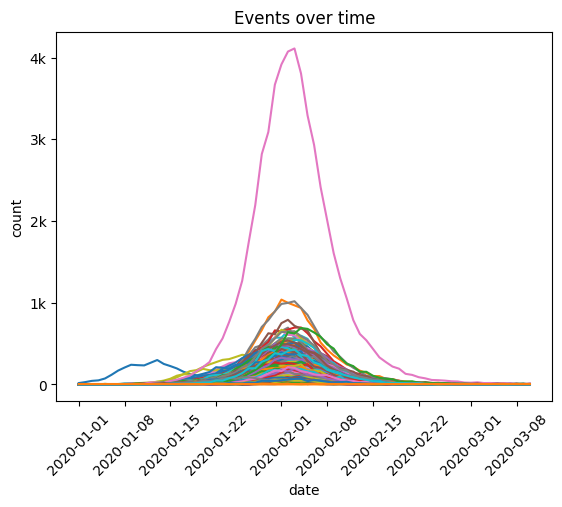

In [ ]:
out_cook_tract.plot.line(
    geo=cook_tract_rume.scope.select.all(),
    time=cook_tract_rume.time_frame.select.all(),
    quantity=cook_tract_rume.ipm.select.events("S->I"),
    title="Events over time",
    # label_format="{q}",
    legend="off",
)